### **Ejercicio N°2**

El dataset `alimentos.csv` fue elaborado por una clínica de nutrición que suministró a sus pacientes una lista de alimentos permitidos con sus respectivos contenidos calóricos. También se detalló el tipo de alimento del que se trataba (fruta, verdura, etc.) y el tipo de vitamina que aportaba cada uno (A, B o C).

Por otra parte, la nutricionista a cargo del estudio lleva una planilla de control de la evolución de 50 pacientes (`pacientes.csv`) en la que registra la edad, el sexo, la altura, el peso inicial y el peso final de cada uno de ellos luego de seguir un plan de dieta por una cierta cantidad de tiempo, información que también fue registrada en el campo “tiempo de tratamiento”.

1. Importe ambos datasets al entorno de trabajo y realice cualquier tarea de limpieza y/o
adecuación de los mismos que considere necesaria.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
alimentos=pd.read_csv('./datasets/alimentos.csv',encoding='latin-1', sep=';')
alimentos.head()

,alimento,aporte_calorico_kcal,tipo_de_alimento,vitamina
0,banana,81,fruta,A
1,kiwi,36,fruta,B
2,higo,62,fruta,B
3,repollo,22,verdura,A
4,col,12,verdura,A


In [3]:
alimentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   alimento              99 non-null     object
 1   aporte_calorico_kcal  99 non-null     int64 
 2   tipo_de_alimento      99 non-null     object
 3   vitamina              99 non-null     object
dtypes: int64(1), object(3)
memory usage: 3.2+ KB


In [4]:
pacientes=pd.read_csv('./datasets/pacientes.csv',encoding='latin-1', sep=';')
pacientes.head()

,codigo_paciente,peso_inicial_kg,peso_final_kg,altura_m,sexo,tiempo_tratamiento_dias
0,398911,78,72,"1,8",F,583
1,398912,68,68,"1,75",F,159
2,398913,92,70,"1,85",F,70
3,398914,66,64,"1,65",M,41
4,398915,51,50,"1,55",F,30


In [5]:
pacientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   codigo_paciente          50 non-null     int64 
 1   peso_inicial_kg          50 non-null     int64 
 2   peso_final_kg            50 non-null     int64 
 3   altura_m                 50 non-null     object
 4   sexo                     50 non-null     object
 5   tiempo_tratamiento_dias  50 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.5+ KB


2. En relación al campo `aporte_calorico_kcal` informe las medidas descriptivas que le brinden información sobre los siguientes aspectos:

- Las kcal que aportan, en promedio, los alimentos que forman parte del dataset.
- Aquel valor de aporte calórico tal que el 50% de los alimentos del dataset presentan aportes calóricos menores o iguales a él.
- La dispersión o variabilidad del 50% central de las observaciones.
- El o los valores que se presentan con mayor frecuencia entre las observaciones.

In [6]:
#Promedio
promedio_calorias=alimentos['aporte_calorico_kcal'].mean()
print(f'Promedio es: {round(promedio_calorias,2)} kcal')
#Mediana 50% valores
median_calorias=alimentos['aporte_calorico_kcal'].median()
print(f'Valor 50% es: {round(median_calorias,2)} kcal')
#Rango intercuartil
cuartilos=alimentos['aporte_calorico_kcal'].quantile(q=[0.25,0.5,0.75])
IQR=cuartilos[0.75]-cuartilos[0.25]
print(f'La dispersion del 50% central es: {round(IQR,2)} kcal')
#Moda
moda=alimentos['aporte_calorico_kcal'].mode().tolist()
print(f'Los valores que mas aparecen son: {moda} kcal')

Promedio es: 124.51 kcal
Valor 50% es: 66.0 kcal
La dispersion del 50% central es: 62.0 kcal
Los valores que mas aparecen son: [20, 75] kcal


3. Represente la distribución de las observaciones de la variable `aporte_calorico_kcal` a través de un boxplot.

- Identifique en el gráfico la mediana, el primer y el tercer cuartil.
- ¿Cómo caracterizaría a la distribución en relación a sus características de simetría?
- En función a lo observado, ¿qué par de medidas de centralidad/posición (media aritmética - mediana) y de dispersión (rango intercuartil - rango - desviación estándar) le parece más adecuada para describir a este conjunto?
- ¿Existe alguna observación que pueda ser considerada como atípica? En caso de respuesta
afirmativa, ¿cuántas observaciones recibirían esta calificación?

Text(0.5, 1.0, 'BoxPlot de las calorias de los alimentos')

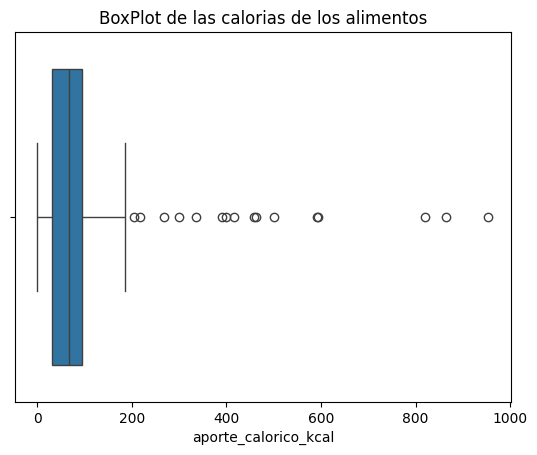

In [7]:
sns.boxplot(x='aporte_calorico_kcal', data=alimentos)
plt.title('BoxPlot de las calorias de los alimentos')

Tiene una asimetria positiva(a la derecha) y las mejores medidas resumen son la mediana porque no es sensible a valores extremos(que hay varios) y el rango intercuartil que muestra el 50% central de los valores

In [8]:
Q1=cuartilos[0.25]
Q2=cuartilos[0.5]
Q3=cuartilos[0.75]

print("--- CUARTILES ---")
print(f"Primer Cuartil (Q1): {Q1:.2f}")
print(f"Mediana (Q2): {Q2:.2f}")
print(f"Tercer Cuartil (Q3): {Q3:.2f}\n")

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers= alimentos[(alimentos['aporte_calorico_kcal']>limite_superior)|(alimentos['aporte_calorico_kcal']<limite_inferior)]
cantidad_atipicos=len(outliers)
print(f'Cantidad de valores atipicos: {cantidad_atipicos}')

--- CUARTILES ---
Primer Cuartil (Q1): 31.50
Mediana (Q2): 66.00
Tercer Cuartil (Q3): 93.50

Cantidad de valores atipicos: 16


4. ¿Qué tipo de alimento presenta la mayor mediana de aporte calórico?

In [9]:
#Tipo de alimento de la mayor mediana 
tipo=alimentos.groupby('tipo_de_alimento')['aporte_calorico_kcal'].median().sort_values(ascending=False).idxmax()
#tipo=alimentos.groupby('tipo_de_alimento')['aporte_calorico_kcal'].median().sort_values(ascending=False).head(1)
print(f'El tipo de alimento con mayor mediana es: {tipo}')

El tipo de alimento con mayor mediana es: elaborada


5. Realice un boxplot para representar la distribución de los aportes calóricos de alimentos de los siguientes tipos: frutas, verduras y alimentos elaborados.
- ¿Qué tipo de alimentos presenta valores calóricos más variables y cuál menos variables?
- ¿Qué medida descriptiva utilizó para responder a estas últimas preguntas?

Text(0.5, 1.0, 'Boxplot de aporte calorico de frutas verduras y elaborados')

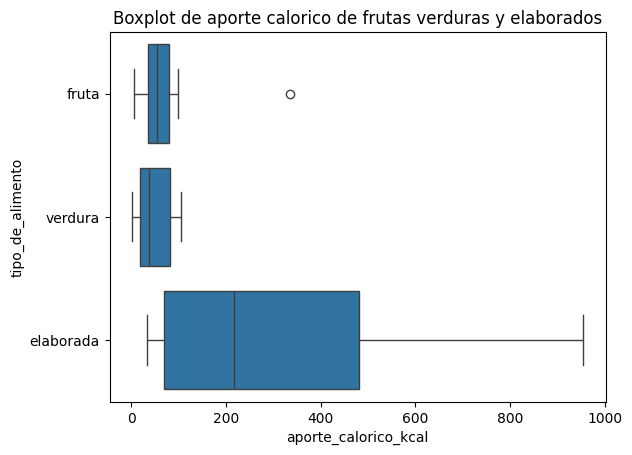

In [10]:
filtro=alimentos[alimentos['tipo_de_alimento'].str.contains('fruta|verdura|elaborada')]
sns.boxplot(data=filtro,x='aporte_calorico_kcal',y='tipo_de_alimento')
plt.title('Boxplot de aporte calorico de frutas verduras y elaborados')

In [11]:
std=filtro.groupby('tipo_de_alimento')['aporte_calorico_kcal'].std()
std

tipo_de_alimento
elaborada    308.898098
fruta         59.138770
verdura       34.535884
Name: aporte_calorico_kcal, dtype: float64

In [12]:
cv=filtro.groupby('tipo_de_alimento')['aporte_calorico_kcal'].std()/filtro.groupby('tipo_de_alimento')['aporte_calorico_kcal'].mean()
cv

tipo_de_alimento
elaborada    0.979320
fruta        0.930057
verdura      0.734806
Name: aporte_calorico_kcal, dtype: float64

Los alimentos elaborados son los que tienen mas variables porque su boxplot es el mas ancho, verduras es el de menos variacion se puede ver en los valores de la desviacion estandar

6. Utilizando los datos de los/las pacientes, genere una variable que corresponda a la variación de peso para cada paciente a lo largo del tratamiento (`peso_final_kg` - `peso_inicial_kg`).
- Represente los valores observados de la variable “diferencia de peso” en función del sexo a través de un boxplot.
- ¿Qué medida descriptiva utilizaría para comparar los resultados del tratamiento entre personas de ambos sexos? En función de su respuesta, ¿las personas de qué sexo obtuvieron los mejores resultados para el tratamiento?

In [13]:
#Genero columna de diferencia de peso de pacientes
pacientes['dif_peso'] = pacientes['peso_final_kg'] - pacientes['peso_inicial_kg']
pacientes.head()

,codigo_paciente,peso_inicial_kg,peso_final_kg,altura_m,sexo,tiempo_tratamiento_dias,dif_peso
0,398911,78,72,"1,8",F,583,-6
1,398912,68,68,"1,75",F,159,0
2,398913,92,70,"1,85",F,70,-22
3,398914,66,64,"1,65",M,41,-2
4,398915,51,50,"1,55",F,30,-1


Text(0.5, 1.0, 'Boxplot diferencia de peso segun sexo')

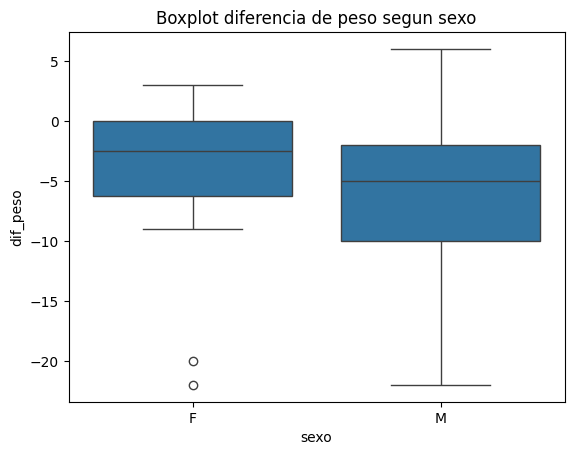

In [14]:
sns.boxplot(x='sexo', y='dif_peso', data=pacientes)
plt.title('Boxplot diferencia de peso segun sexo')

In [15]:
pacientes.groupby('sexo')['dif_peso'].median()

sexo
F   -2.5
M   -5.0
Name: dif_peso, dtype: float64

Los hombres son los que mas bajaron de peso en la clinica